Análisis Exploratorio de Factores de Abandono de Clientes (Churn)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv("Bank Customer Churn Prediction.csv")
df

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [11]:
# 1. Revisar si existen valores duplicados o nulos
df.duplicated().sum()
df.isna().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 1.0 MB


In [15]:
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [18]:
df["churn"].value_counts()

churn
0    7963
1    2037
Name: count, dtype: int64

<Axes: xlabel='churn', ylabel='age'>

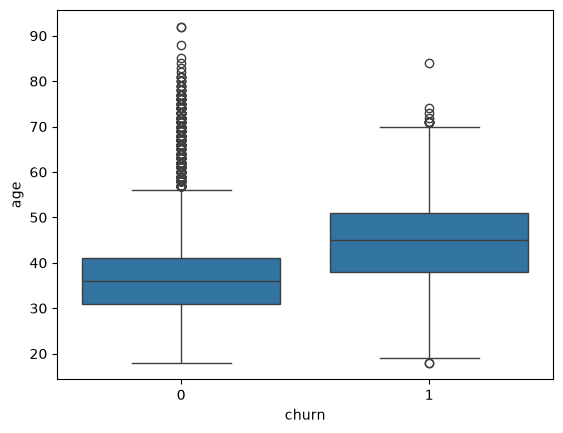

In [25]:
sns.boxplot( x= "churn", y="age", data= df)

In [36]:
from scipy import stats

# Separaramos las edades de los dos grupos
edades_no_churn = df[df['churn'] == 0]['age']
edades_churn = df[df['churn'] == 1]['age']

# Aplicar la prueba de Mann-Whitney U
stat, p_value = stats.mannwhitneyu(edades_churn, edades_no_churn)

print(f"Estadístico U: {stat}")
print(f"P-value: {p_value}")

Estadístico U: 11874649.5
P-value: 3.2104014319371675e-230


Hllazgo 1. la diferencia de edad entre los clientes que se van y los que se quedan no es producto del azar; existe una correlación y significancia estadística abrumadora. Los clientes de mayor edad abandonan el banco a un ritmo significativamente distinto.

In [27]:
print(pd.crosstab(df['country'], df['churn'], normalize='index') * 100)

churn            0          1
country                      
France   83.845233  16.154767
Germany  67.556796  32.443204
Spain    83.326605  16.673395


<Axes: xlabel='churn', ylabel='estimated_salary'>

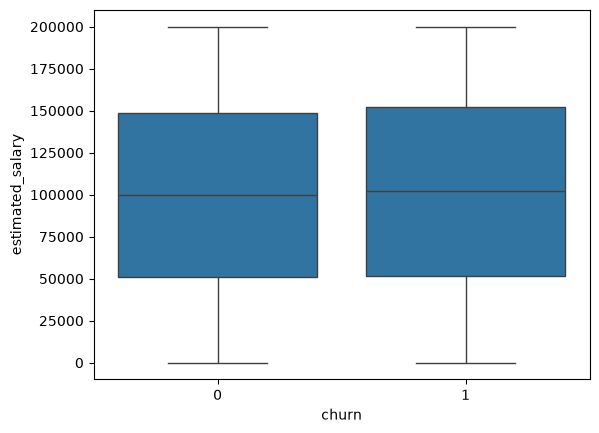

In [30]:
sns.boxplot(x='churn', y='estimated_salary', data=df)

In [32]:
print(pd.crosstab(df['products_number'], df['churn'], normalize='index') * 100)

churn                    0           1
products_number                       
1                72.285602   27.714398
2                92.418301    7.581699
3                17.293233   82.706767
4                 0.000000  100.000000


In [37]:
from scipy.stats import chi2_contingency

# Crear la tabla de contingencia (sin normalizar)
tabla_contingencia = pd.crosstab(df['products_number'], df['churn'])

# Aplicar Chi-cuadrado
chi2, p_val, dof, ex = chi2_contingency(tabla_contingencia)

print(f"Estadístico Chi2: {chi2}")
print(f"P-value: {p_val}")

Estadístico Chi2: 1503.6293615070408
P-value: 0.0


Hallazgo 2: El test de Chi-cuadrado confirma con absoluta certeza matemática que el número de productos y el abandono están fuertemente asociados. No es una coincidencia visual: tener 3 o más productos dispara el riesgo de fuga de manera crítica.
De los clientes que tienen 3 productos, el 82.7% se va, y de los que tienen 4, el 100% abandona la entidad.

In [34]:
df

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [35]:
print(pd.crosstab(df["active_member"], df["churn"], normalize= "index")*100)

churn                  0          1
active_member                      
0              73.149103  26.850897
1              85.730926  14.269074


0 (No activo): El 26.85% de estos clientes abandonan el banco.

1 (Activo): El porcentaje de abandono baja casi a la mitad, situándose en un 14.27%.

La inactividad es un claro detonante de fuga. Los clientes que no interactúan de forma constante con el banco tienen casi el doble de probabilidades de irse en comparación con los que sí son activos.